# Multivariate Chemometric Reaction Fingerprints & Extent Inversion

**Project:** BatteryAsTank / Atom-to-Reactor  
**Author:** Yeray Alcaraz Galván  
**Affiliation:** Department of Chemistry – Ångström Laboratory, Uppsala University  
**Supervisor:** Prof. Peter Broqvist  

This notebook implements multivariate multi-nuclear chemometric reaction fingerprints ($\mathbf{F} = \mathbf{S} \cdot \mathbf{P}_{\text{pure}}$) across $^{29}\text{Si}, ^{31}\text{P}, ^{13}\text{C}, ^{1}\text{H}$. It performs:
1. **SVD Identifiability Analysis**: Proves that 6 of 9 elementary reactions are linearly independent.
2. **Net Analyte Signal (NAS) & Nuclear Selectivity**: Identifies which nucleus distinguishes each reaction.
3. **Extent Recovery ($\Delta \boldsymbol{\xi}$)**: Deconvolutes experimental/synthetic noisy spectra using the pseudoinverse $(\mathbf{F}_{\mathcal{B}}^\dagger)$.


In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kinetics import (
    simulate_protocol_reactor,
    compute_recipe_molarities,
    build_referenced_nmr_sites,
    build_multinuclear_feature_space,
    build_pure_component_matrix,
    build_reaction_fingerprints,
    analyze_reaction_identifiability,
    recover_reaction_extents,
    DEFAULT_NUCLEI
)

# Plotting publication style
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif',
    'figure.dpi': 150,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

print("Imports ready.")


Imports ready.


## 1. Multi-nuclear Feature Space & Pure Component Spectra

Concatenates the four frequency grids (Si, P, C, H) and builds the pure-component spectral matrix $\mathbf{P}_{\text{pure}}$.


In [2]:
catalog = build_referenced_nmr_sites()
species = ['TMSPA', 'BMSPA', 'MMSPA', 'H3PO4', 'H2O', 'TMSOH', 'HMDSO', 'TMSOEG', 'TMSOdiEG', 'CO2']
visible = [sp for sp in species if sp != 'EC' and any(not lab for el in ['Si', 'P', 'C', 'H'] for _, _, lab in catalog.get(el, {}).get(sp, []))]

grids, x_concat, blocks, n_feat = build_multinuclear_feature_space(visible, catalog)
p_pure = build_pure_component_matrix(visible, x_concat, blocks, n_feat, catalog)

print(f"Visible species ({len(visible)}): {', '.join(visible)}")
print(f"Total concatenated feature dimensions: {n_feat} features across 4 nuclei.")


Visible species (9): TMSPA, BMSPA, MMSPA, H3PO4, TMSOH, HMDSO, TMSOEG, TMSOdiEG, CO2
Total concatenated feature dimensions: 4200 features across 4 nuclei.


## 2. Multi-nuclear Reaction Fingerprints & SVD Identifiability

Computes stoichiometric fingerprints $\mathbf{F} = \mathbf{S} \cdot \mathbf{P}_{\text{pure}}$ with block variance normalization. Analyzes mathematical identifiability via SVD.


In [3]:
rxns = [
    ('R1', ['TMSPA', 'H2O'],   ['BMSPA',    'TMSOH']),
    ('R2', ['BMSPA', 'H2O'],   ['MMSPA',    'TMSOH']),
    ('R3', ['MMSPA', 'H2O'],   ['H3PO4',    'TMSOH']),
    ('R4', ['TMSOH', 'TMSOH'], ['HMDSO',    'H2O']),
    ('R5', ['TMSPA', 'TMSOH'], ['BMSPA',    'HMDSO']),
    ('R6', ['BMSPA', 'TMSOH'], ['MMSPA',    'HMDSO']),
    ('R7', ['MMSPA', 'TMSOH'], ['H3PO4',    'HMDSO']),
    ('R8', ['EC',    'TMSOH'], ['TMSOEG',   'CO2']),
    ('R9', ['EC',    'TMSOEG'], ['TMSOdiEG', 'CO2']),
]

f_norm, f_raw, weights, s_vis = build_reaction_fingerprints(rxns, visible, p_pure, blocks)
analysis = analyze_reaction_identifiability(f_norm, f_raw, [r[0] for r in rxns], blocks)

print(f"Reaction Network Numerical Rank: {analysis['effective_rank']} of {len(rxns)} elementary steps.")
print(f"Linearly Independent (Lumped) Basis Reactions:")
for label in analysis['lumped_labels']:
    print(f"  • {label}")


Reaction Network Numerical Rank: 6 of 9 elementary steps.
Linearly Independent (Lumped) Basis Reactions:
  • R1 ⊕ R5
  • R2 ⊕ R6
  • R3 ⊕ R7
  • R4 ⊕ R5,R6,R7
  • R8
  • R9


## 3. Net Analyte Signal (NAS) & Nuclear Selectivity Matrix

Quantifies the exclusive orthogonal signal fraction per nucleus:
$$\text{sel}_{j, X} = \frac{\|\mathbf{NAS}_{j, X}\|_2}{\|\mathbf{f}_{j, X}\|_2} \in [0, 1]$$


In [4]:
sel_df = analysis['selectivity_df']
print("Nuclear Selectivity Table:")
sel_df.round(2)


Nuclear Selectivity Table:


,29Si,31P,13C,1H,all nuclei
R1 ⊕ R5,0.92,0.82,0.97,0.85,0.98
R2 ⊕ R6,0.88,0.71,0.91,0.83,0.96
R3 ⊕ R7,0.82,0.82,0.81,0.86,0.94
"R4 ⊕ R5,R6,R7",0.79,NaN,0.89,0.92,0.94
R8,0.10,NaN,0.84,0.65,0.77
R9,0.10,NaN,0.98,0.68,0.82


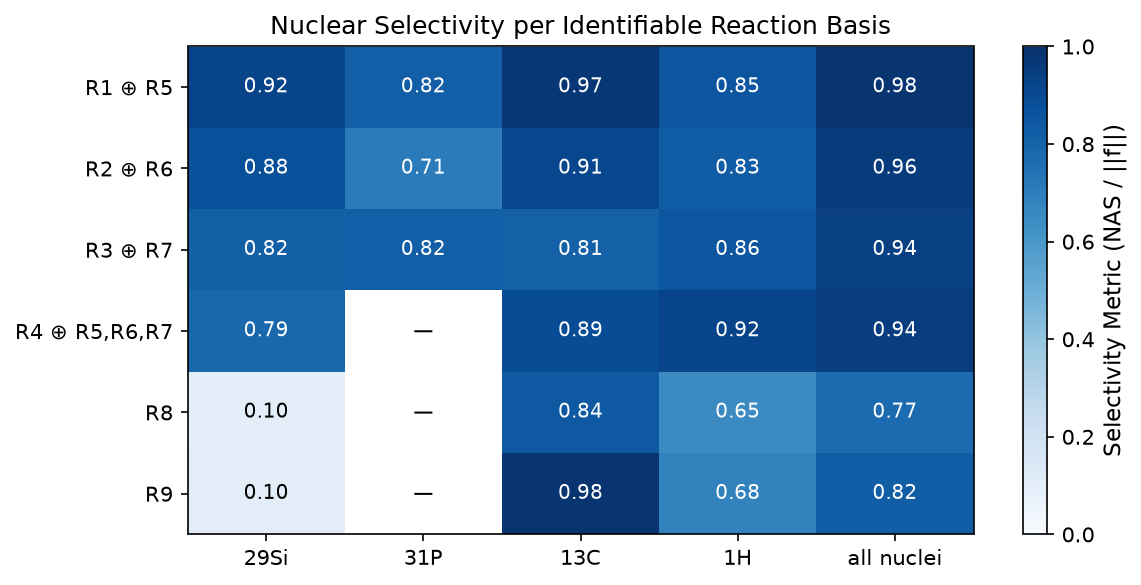

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
masked = np.ma.masked_invalid(sel_df.values)
cax = ax.imshow(masked, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(sel_df.columns)))
ax.set_xticklabels(sel_df.columns, fontsize=10)
ax.set_yticks(range(len(sel_df.index)))
ax.set_yticklabels(sel_df.index, fontsize=10)

for (j, c), v in np.ndenumerate(sel_df.values):
    ax.text(c, j, '—' if np.isnan(v) else f"{v:.2f}", ha='center', va='center',
            color='white' if not np.isnan(v) and v > 0.6 else 'black', fontsize=9.5)

plt.colorbar(cax, label='Selectivity Metric (NAS / ||f||)')
plt.title('Nuclear Selectivity per Identifiable Reaction Basis')
plt.tight_layout()
plt.show()


## 4. Reaction Extent Recovery from Synthetic Operando Spectra with Noise

Simulates noisy multi-nuclear difference spectra ($\Delta \mathbf{D} + \sigma$) across the 7 temperature steps and inverts them to recover per-step reaction extents $\Delta \boldsymbol{\xi}$.


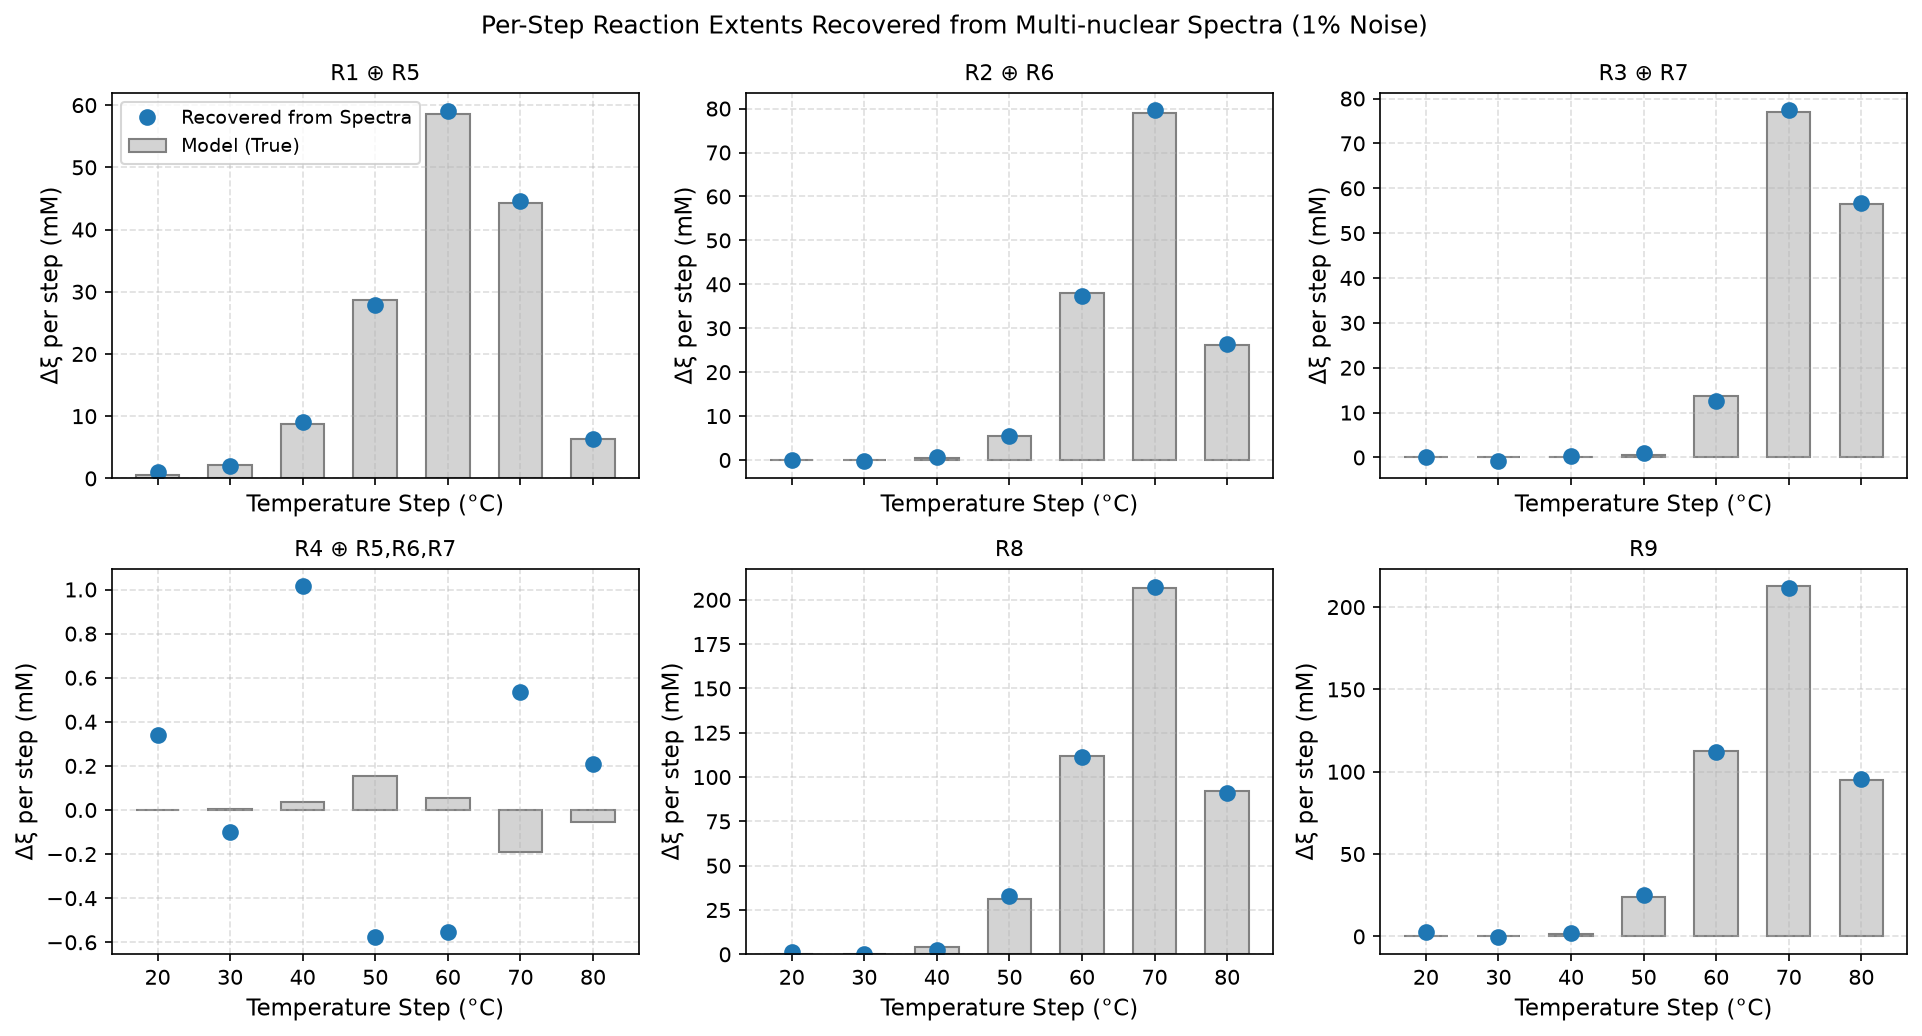

In [6]:
# Run protocol simulation
recipe = compute_recipe_molarities()
sim = simulate_protocol_reactor(recipe=recipe, points_per_stage=30)

points_per_stage = 30
injection_stage_idx = 2
i0 = injection_stage_idx * points_per_stage
stages = sim['stages']
i_snaps = [(i + 1) * points_per_stage - 1 for i, st in enumerate(stages) if st[3] is not None]
step_idx = [i0] + i_snaps
step_temps = [s['T_C'] for s in sim['snapshots']]

vis_idx = [sim['idx'][sp] for sp in visible]
c_vis_snapshots = sim['C_M'][vis_idx][:, step_idx]  # (vis, 8)

# True noise-free spectra
d_true = (c_vis_snapshots.T * 1000.0) @ p_pure

# Add 1% synthetic experimental noise
NOISE_REL = 0.01
rng = np.random.default_rng(42)
d_meas = d_true.copy()
for el, sl in blocks.items():
    sigma = NOISE_REL * np.abs(d_true[:, sl]).max()
    d_meas[:, sl] += rng.normal(0, sigma, d_true[:, sl].shape)

# Step differences
dD = np.diff(d_meas, axis=0)

# Pseudoinverse inversion
xi_hat = recover_reaction_extents(dD, analysis['F_basis_norm'], weights)

# Compare with true stoichiometric extents
dD_true = np.diff(d_true, axis=0)
xi_true = recover_reaction_extents(dD_true, analysis['F_basis_norm'], weights)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for j, ax in enumerate(axes.flat):
    if j < len(analysis['lumped_labels']):
        ax.bar(step_temps, xi_true[:, j], width=6, color='lightgray', edgecolor='gray', label='Model (True)')
        ax.plot(step_temps, xi_hat[:, j], 'o', color='C0', ms=7, label='Recovered from Spectra')
        ax.set_title(analysis['lumped_labels'][j], fontsize=10.5)
        ax.set_ylabel('Δξ per step (mM)')
        ax.grid(True)
        if j == 0:
            ax.legend(frameon=True)
    else:
        ax.set_visible(False)
    ax.set_xlabel('Temperature Step (°C)')

plt.suptitle(f"Per-Step Reaction Extents Recovered from Multi-nuclear Spectra ({NOISE_REL:.0%} Noise)")
plt.tight_layout()
plt.show()
